In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import matplotlib.patches as patches
from scipy.io import loadmat
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.text import Text
from matplotlib.legend_handler import HandlerLine2D

import matplotlib.image as mpimg
import matplotlib.patches as patches



In [2]:
path_csv = os.path.abspath('../8_Convergence_Test/')
delta = np.array([0.1, 1, 5, 10, 15, 20, 50])

In [3]:
def PG_time_extractor(lines):
    # find table start
    start=None
    for i,l in enumerate(lines):
        if l.strip().startswith("Performance Graph"):
            start=i
            break
            
    # find first table row
    table_lines=[]
    if start is not None:
        for l in lines[start+1:]:
            if l.strip().startswith('|'):
                table_lines.append(l.rstrip("\n"))
            elif table_lines:
                if not l.strip().startswith('-'):
                    break
    
    # split table rows
    rows=[]
    for l in table_lines:
        parts=[p.strip() for p in l.strip('|').split('|')]
        if len(parts)>2:
            rows.append(parts)
    
    # locate header row
    header=None
    for r in rows:
        if r[0].startswith("Section"):
            header=r
            break
    
    # extract data rows
    data=[]
    capture=False
    for r in rows:
        if r == header:
            capture=True
            continue
        if capture:
            data.append(r)
    
    df=pd.DataFrame(data, columns=header)
    
    # extract total time for main
    total_sim_time=float(df.loc[df['Section']=="tumbleweedTestApp (main)", "Total(s)"].iloc[0])
    
    return df, total_sim_time

In [4]:
delta_0_1_csv = pd.read_csv(path_csv+'/0_1/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/0_1/output.txt') as f: delta_0_1_PG=f.readlines()
PG_0_1 = PG_time_extractor(delta_0_1_PG)


delta_1_csv = pd.read_csv(path_csv+'/1/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/1/output.txt') as f: delta_1_PG=f.readlines()
PG_1 = PG_time_extractor(delta_1_PG)
    
delta_5_csv = pd.read_csv(path_csv+'/5/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/5/output.txt') as f: delta_5_PG=f.readlines()
PG_5 = PG_time_extractor(delta_5_PG)

delta_10_csv = pd.read_csv(path_csv+'/10/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/10/output.txt') as f: delta_10_PG=f.readlines()
PG_10 = PG_time_extractor(delta_10_PG)

delta_15_csv = pd.read_csv(path_csv+'/15/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/15/output.txt') as f: delta_15_PG=f.readlines()
PG_15 = PG_time_extractor(delta_15_PG)

delta_20_csv = pd.read_csv(path_csv+'/20/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/20/output.txt') as f: delta_20_PG=f.readlines()
PG_20 = PG_time_extractor(delta_20_PG)

delta_50_csv = pd.read_csv(path_csv+'/50/exodus/TPF.csv',     encoding='utf-8')
with open(path_csv+'/50/output.txt') as f: delta_50_PG=f.readlines()
PG_50 = PG_time_extractor(delta_50_PG)

In [5]:
PG_0_1[1], PG_1[1], PG_5[1], PG_10[1], PG_15[1], PG_20[1], PG_50[1]

(3683.452, 2601.855, 2618.842, 2517.669, 2540.199, 2356.134, 2073.157)

In [6]:
delta_0_1_csv['time'][10], delta_1_csv['time'][10], delta_5_csv['time'][10], delta_10_csv['time'][10], delta_15_csv['time'][10], delta_20_csv['time'][10], delta_50_csv['time'][10], 

(np.float64(3.2186508178711e-08),
 np.float64(1.4762878417969e-05),
 np.float64(3.84521484375e-05),
 np.float64(0.00012451171875),
 np.float64(0.000146484375),
 np.float64(0.0003515625),
 np.float64(0.001640625))

In [196]:
sim_times = [delta_0_1_csv['time'][10], delta_1_csv['time'][10], delta_5_csv['time'][10], delta_10_csv['time'][10], delta_15_csv['time'][10], delta_20_csv['time'][10], delta_50_csv['time'][10], ]
cpu_times = [PG_0_1[1], PG_1[1], PG_5[1], PG_10[1], PG_15[1], PG_20[1], PG_50[1]]

In [38]:
delta_0_1_csv.columns

Index(['time', 'area_h1', 'dt', 'temp_avg', 'temp_max', 'temp_min'], dtype='object')

In [6]:
temp_max_at10 = [delta_0_1_csv['temp_max'][10], delta_1_csv['temp_max'][10], delta_5_csv['temp_max'][10], delta_10_csv['temp_max'][10], delta_15_csv['temp_max'][10], delta_20_csv['temp_max'][10], delta_50_csv['temp_max'][10], ]
temp_max_at10

[np.float64(300.75077830588),
 np.float64(532.30280715894),
 np.float64(412.95765723678),
 np.float64(485.94383458431),
 np.float64(456.82969419872),
 np.float64(559.14749100673),
 np.float64(1740.9983749892)]

In [ ]:
300.75
532.30
412.95
485.94
456.82
559.14

In [15]:
delta_0_1_csv.head()

,time,area_h1,dt,temp_avg,temp_max,temp_min
0,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
1,8.940697e-10,2427.156184,8.940697e-10,300.000414,300.038596,299.999975
2,1.788139e-09,1993.011721,8.940697e-10,300.000747,300.054062,299.999908
3,2.682209e-09,1520.667107,8.940697e-10,300.001055,300.064237,299.999817
4,3.576279e-09,1080.221121,8.940697e-10,300.001372,300.082222,299.999707


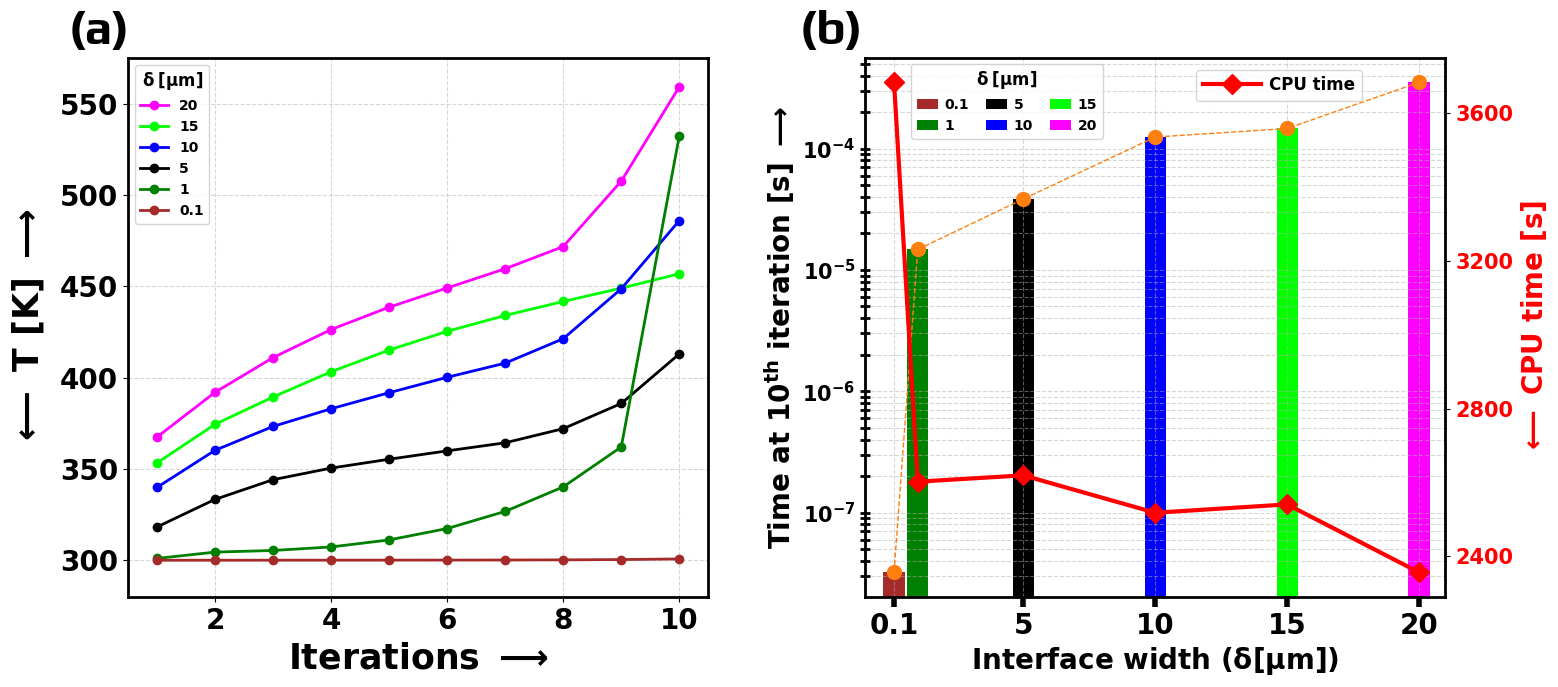

In [283]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[17, 7], frameon=False)
ax1.set_facecolor((0, 0, 0, 0))
ax2.set_facecolor((0, 0, 0, 0))

colors = ['brown', 'green', 'black', 'blue', 'lime', 'magenta', 'red']
interface_width = [r'0.1', '1', '5', '10', '15', '20', '50']



# ax1.plot(delta_50_csv['temp_max'][1:], '-o', color='red', linewidth=2,  label=r'$\mathbf{\delta=50\mu m}$')
ax1.plot(delta_20_csv['temp_max'][1:], '-o', color='magenta', linewidth=2,  label=r'20')
ax1.plot(delta_15_csv['temp_max'][1:], '-o', color='lime', linewidth=2,  label=r'15')
ax1.plot(delta_10_csv['temp_max'][1:], '-o', color='blue', linewidth=2,  label=r'10')
ax1.plot(delta_5_csv['temp_max'][1:], '-o', color='black', linewidth=2,  label=r'5')
ax1.plot(delta_1_csv['temp_max'][1:], '-o', color='green', linewidth=2,  label=r'1')
ax1.plot(delta_0_1_csv['temp_max'][1:], '-o', color='brown', linewidth=2,  label=r'0.1')
ax1.set_yticks([300, 350, 400, 450, 500, 550], labels=[300, 350, 400, 450, 500, 550], size=20, color='k', weight='bold')
ax1.set_xticks([2, 4, 6, 8, 10], labels=[2, 4, 6, 8, 10], size=20, weight='bold', color='k', rotation=0)
ax1.set_ylim(280, 575)
ax1.set_xlim(0.5, 10.5)
ax1.grid(True, which="both", linestyle="--", alpha=0.5)
ax1.set_ylabel(r"$\mathbf{\longleftarrow}$ T [K] $\mathbf{\longrightarrow}$", loc='center',  weight = 'bold', labelpad=10, size=25, color='k')
ax1.set_xlabel(r"Iterations $\mathbf{\longrightarrow}$", loc='center',  weight = 'bold', labelpad=5, size=25, color='k')
ax1.legend(title=r"$\mathbf{\delta\;[\mu m]}$", title_fontsize=12, prop={'weight':'bold', 'size':'10',})
ax1.spines[:].set_linewidth(2)



ax2.semilogy(delta[:-1], sim_times[:-1], marker='o', linewidth=1, linestyle='--', markersize=10, color='tab:orange')
for i in range(len(delta)-1):
    ax2.bar(delta[i], sim_times[i], color=colors[i], label=interface_width[i], )
ax2.set_xticks([0.1, 5, 10, 15, 20], labels=[0.1, 5, 10, 15, 20], size=20, weight='bold', color='k', rotation=0)
ax2.set_yticks([1e-7, 1e-6, 1e-5, 1e-4], labels=[r'10$^\mathbf{-7}$', r'10$^\mathbf{-6}$', r'10$^\mathbf{-5}$', r'10$^\mathbf{-4}$'], size=15, color='k', weight='bold')
ax2.set_xlabel(r"Interface width ($\mathbf{\delta [\mu m]}$)", weight='bold', size=20)
ax2.set_ylabel(r"Time at 10$^\mathbf{th}$ iteration [s] $\mathbf{\longrightarrow}$", weight='bold', size=20)
ax2.grid(True, which="both", linestyle="--", alpha=0.5)
ax2.legend(loc=(0.08, 0.85), ncol=3, columnspacing=1.2, handlelength=1.5, handletextpad=0.5, title=r"$\mathbf{\delta\;[\mu m]}$", title_fontsize=12, prop={'weight':'bold', 'size':'10',}, frameon=True)
ax2.spines[:].set_linewidth(2)
ax2.set_xlim(-1, 21)
ax2.tick_params(axis='y', which='both', direction='inout', length=7, width=2, color='k')
ax2.tick_params(axis='x', which='both', direction='out', length=7, width=4, color='k')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.27, hspace=0.1)

ax3 = ax2.twinx()
ax3.plot(delta[:-1], cpu_times[:-1], marker='D', markersize=10, linestyle='-', color='red', linewidth=3, label=r'CPU time')
ax3.legend(loc=(0.57, 0.92), ncol=1, handlelength=3.5, handletextpad=0.5, prop={'weight':'bold', 'size':'12',}, frameon=True)
ax3.set_yticks([2400, 2800, 3200, 3600], labels=[2400, 2800, 3200, 3600], size=15, color='red', weight='bold')
ax3.set_ylabel(r"$\mathbf{\longleftarrow}$ CPU time [s]", weight='bold', size=20, color='red')

text_a = Text(x=0.09, y=0.9, text=r'(a)', fontsize=35, color='k', rotation=0, weight='bold', fontname='Play')
text_b = Text(x=0.52, y=0.9, text=r'(b)', fontsize=35, color='k', rotation=0, weight='bold', fontname='Play')
fig.add_artist(text_a)
fig.add_artist(text_b)

# plt.savefig('figures/convergence_result.png',bbox_inches='tight', dpi=800)
# plt.savefig('figures/convergence_result.jpg',bbox_inches='tight',)


plt.show()